# Análise do experimento v4 — crédito por caso na vigilância de arboviroses

Este notebook reúne as medições que sustentam a conclusão da fase v4: **o que
destravou o agente foi a atribuição de crédito no aprendiz**, não a observação
nem a correção do modelo epidêmico.

O que está aqui:

1. **Os três braços** (A, B, C) e o que cada contraste isola.
2. **Curvas de treino**, por época e por seed.
3. **Comparação de todos os agentes** que o projeto tem, na mesma distribuição.
4. **O modelo epidêmico**, antes e depois da correção.
5. **O último dia da epidemia**, com as decisões de cada agente, em duas seeds.

Tudo é recalculado a partir dos CSVs de benchmark e de episódios rodados na
hora — nenhum número é digitado à mão.

Detalhamento do desenho experimental em `EXPERIMENTO_V4.md`.

In [1]:
from pathlib import Path
import os, re, sys, time, warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yaml

warnings.filterwarnings("ignore")
RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(RAIZ))
# Os caminhos dos YAMLs (superfícies de kriging, checkpoints) são relativos à
# raiz do repositório, não ao diretório do notebook.
os.chdir(RAIZ)

SAIDA = RAIZ / "results" / "analise_v4"
SAIDA.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 150, "font.size": 9,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "figure.facecolor": "white",
})

# Paleta estável: o mesmo braço tem a mesma cor em todas as figuras.
COR = {"A": "#b8912f", "B": "#2d6fb5", "C": "#1f8a5f",
       "fixa": "#8a8a8a", "alvo": "#c2453a"}

BRACOS = {
    "A — GAE padrão":            ("ppo_v4a_seir", "A"),
    "B — crédito + temporais":   ("ppo_v4b_credito", "B"),
    "C — crédito, sem temporais":("ppo_v4c_credito_sem_tempo", "C"),
}
SEEDS_TREINO = (45, 46, 47)
print("raiz:", RAIZ)

raiz: C:\Users\segun\Documents\GitHub\Dengue_Diagnostics


## 1. Os três braços

Todos treinaram no **mesmo ambiente** (kriging do Rio com SEIR de literatura),
com os mesmos hiperparâmetros e 300 mil passos. O que muda:

| braço | crédito (aprendiz) | observação |
|---|---|---|
| **A** | GAE padrão | 16 dims de contexto |
| **B** | por caso, desconto em dias | 16 + 4 temporais |
| **C** | por caso, desconto em dias | 16 dims (**igual ao A**) |

`A × C` isola o crédito — a observação é idêntica.
`B × C` isola as features temporais — o crédito é idêntico.

Avaliação: **checkpoint final** (nunca o `best`, que seleciona ruído), em 10
seeds fixas de avaliação, para cada uma das 3 seeds de treino.

In [2]:
def carrega_braco(run):
    linhas = []
    for s in SEEDS_TREINO:
        p = RAIZ / f"results/bm_{run}_s{s}/benchmark_mean.csv"
        r = pd.read_csv(p, index_col=0).loc["ppo"]
        linhas.append({"seed_treino": s,
                       "recompensa": r["Recompensa Total"],
                       "acuracia": r["Acurácia Multiclasse"],
                       "exames": r["Testes Realizados"]})
    return pd.DataFrame(linhas)

por_seed = pd.concat(
    [carrega_braco(run).assign(braco=nome) for nome, (run, _) in BRACOS.items()]
)

resumo = (por_seed.groupby("braco")
          .agg(recompensa=("recompensa", "mean"), desvio=("recompensa", "std"),
               acuracia=("acuracia", "mean"), exames=("exames", "mean"))
          .round(3).sort_values("recompensa", ascending=False))

# Baselines do mesmo ambiente (10 seeds, políticas fixas).
base = pd.read_csv(RAIZ / "results/baseline_v8seir_kriging/benchmark_mean.csv", index_col=0)
ALVO = base.loc["testonce", "Recompensa Total"]
PISO = base.loc["clinical", "Recompensa Total"]

print(f"referências do ambiente:  testonce {ALVO:+.1f}   clinical {PISO:+.1f}\n")
display(resumo)
print("\npor seed de treino:")
display(por_seed.pivot(index="seed_treino", columns="braco", values="recompensa").round(1))

referências do ambiente:  testonce +2782.1   clinical -64.1



,recompensa,desvio,acuracia,exames
braco,,,,
"C — crédito, sem temporais",2677.967,48.176,0.936,281.133
B — crédito + temporais,2649.300,49.555,0.931,265.733
A — GAE padrão,729.367,118.480,0.743,30.067



por seed de treino:


braco,A — GAE padrão,B — crédito + temporais,"C — crédito, sem temporais"
seed_treino,,,
45,843.9,2706.1,2681.1
46,607.3,2614.9,2628.3
47,736.9,2626.9,2724.5


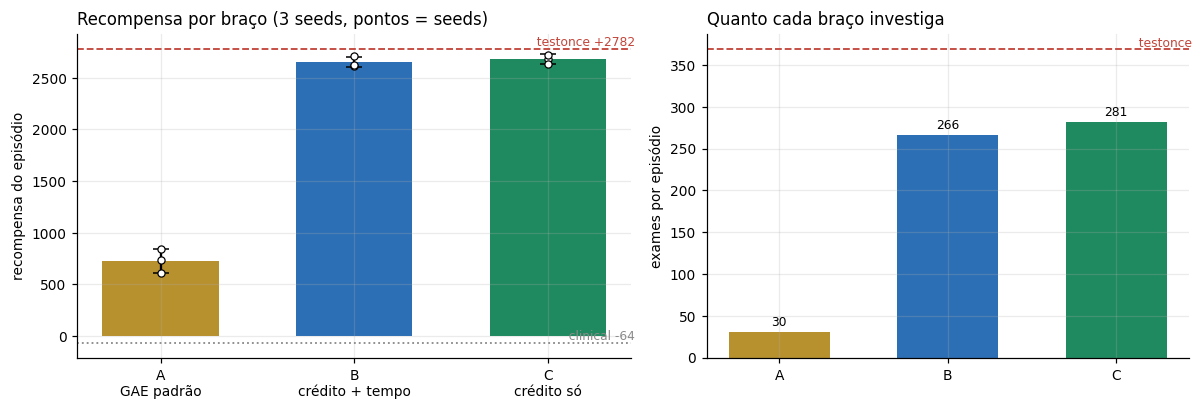

A → C (só o crédito muda) : +1949
C → B (só a observação)   : -29   (desvio típico entre seeds: ±72)


In [3]:
fig, (ax, ax2) = plt.subplots(1, 2, figsize=(11, 3.8), gridspec_kw={"width_ratios": [1.15, 1]})

ordem = ["A — GAE padrão", "B — crédito + temporais", "C — crédito, sem temporais"]
x = np.arange(len(ordem))
m = [resumo.loc[b, "recompensa"] for b in ordem]
e = [resumo.loc[b, "desvio"] for b in ordem]
cores = [COR[BRACOS[b][1]] for b in ordem]

ax.bar(x, m, yerr=e, capsize=5, color=cores, width=0.6)
for i, b in enumerate(ordem):                      # seeds individuais
    pontos = por_seed.query("braco == @b")["recompensa"]
    ax.scatter([i] * len(pontos), pontos, color="white", edgecolor="black",
               zorder=3, s=22, linewidth=0.8)
ax.axhline(ALVO, color=COR["alvo"], ls="--", lw=1.2)
ax.text(2.45, ALVO, f"  testonce {ALVO:+.0f}", color=COR["alvo"], va="bottom", ha="right", fontsize=8)
ax.axhline(PISO, color=COR["fixa"], ls=":", lw=1.2)
ax.text(2.45, PISO, f"  clinical {PISO:+.0f}", color=COR["fixa"], va="bottom", ha="right", fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(["A\nGAE padrão", "B\ncrédito + tempo", "C\ncrédito só"])
ax.set_ylabel("recompensa do episódio")
ax.set_title("Recompensa por braço (3 seeds, pontos = seeds)", loc="left")

# Exames: a competência que separa os braços.
ex = [resumo.loc[b, "exames"] for b in ordem]
ax2.bar(x, ex, color=cores, width=0.6)
ax2.axhline(base.loc["testonce", "Testes Realizados"], color=COR["alvo"], ls="--", lw=1.2)
ax2.text(2.45, base.loc["testonce", "Testes Realizados"], "  testonce", color=COR["alvo"],
         va="bottom", ha="right", fontsize=8)
for i, v in enumerate(ex):
    ax2.text(i, v + 8, f"{v:.0f}", ha="center", fontsize=8)
ax2.set_xticks(x); ax2.set_xticklabels(["A", "B", "C"])
ax2.set_ylabel("exames por episódio")
ax2.set_title("Quanto cada braço investiga", loc="left")

fig.tight_layout(); fig.savefig(SAIDA / "bracos.png", bbox_inches="tight")
plt.show()

d_credito = resumo.loc["C — crédito, sem temporais", "recompensa"] - resumo.loc["A — GAE padrão", "recompensa"]
d_tempo = resumo.loc["B — crédito + temporais", "recompensa"] - resumo.loc["C — crédito, sem temporais", "recompensa"]
print(f"A → C (só o crédito muda) : {d_credito:+.0f}")
print(f"C → B (só a observação)   : {d_tempo:+.0f}   "
      f"(desvio típico entre seeds: ±{resumo['desvio'].mean():.0f})")

**Leitura.** O efeito do crédito é ~40× maior que o desvio entre seeds; o efeito
das features temporais é *menor* que esse desvio, e de sinal negativo. Em outras
palavras: o braço C (mais simples) não é pior que o B.

## 2. Curvas de treino

Recompensa de avaliação ao fim de cada época, lida dos logs de treino. Os
valores do log estão na escala interna do treino (`reward_scale` = 0,10);
aqui são reconvertidos para a escala do ambiente.

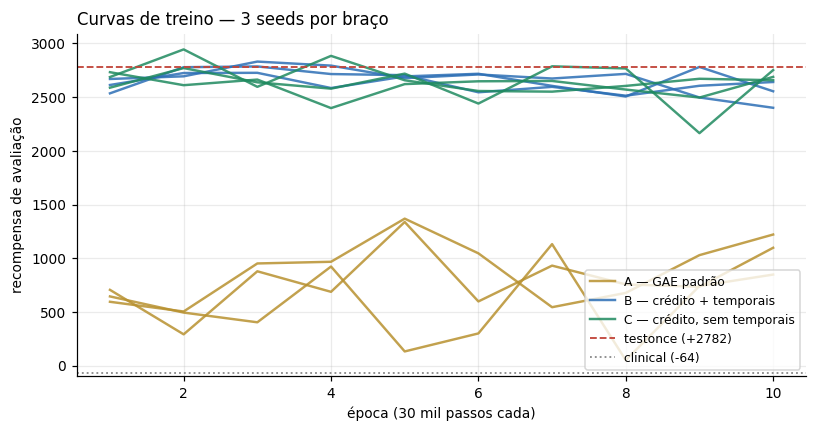

Obs.: as curvas do braço C começam na época 1 porque as seeds foram
retreinadas do zero após quedas da máquina (ver EXPERIMENTO_V4.md §7).


In [4]:
ESCALA = 10.0   # inverso de reward_scale: 0,10

def curva(run, seed):
    p = RAIZ / f"results/logs_v4/{run}_s{seed}.train.log"
    if not p.exists():
        return None
    txt = p.read_text(encoding="utf-8", errors="ignore").replace("\r", "\n")
    vals = [float(m.group(1)) * ESCALA
            for m in re.finditer(r"Epoch #\d+: test_reward: ([-\d.]+)", txt)]
    return vals or None

fig, ax = plt.subplots(figsize=(7.5, 4))
for nome, (run, k) in BRACOS.items():
    for i, s in enumerate(SEEDS_TREINO):
        v = curva(run, s)
        if not v:
            continue
        ax.plot(range(1, len(v) + 1), v, color=COR[k], alpha=0.85, lw=1.6,
                label=nome if i == 0 else None)
ax.axhline(ALVO, color=COR["alvo"], ls="--", lw=1.2, label=f"testonce ({ALVO:+.0f})")
ax.axhline(PISO, color=COR["fixa"], ls=":", lw=1.2, label=f"clinical ({PISO:+.0f})")
ax.set_xlabel("época (30 mil passos cada)"); ax.set_ylabel("recompensa de avaliação")
ax.set_title("Curvas de treino — 3 seeds por braço", loc="left")
ax.legend(fontsize=8, loc="lower right")
fig.tight_layout(); fig.savefig(SAIDA / "curvas_treino.png", bbox_inches="tight")
plt.show()

print("Obs.: as curvas do braço C começam na época 1 porque as seeds foram")
print("retreinadas do zero após quedas da máquina (ver EXPERIMENTO_V4.md §7).")

**Leitura.** Os braços com crédito por caso chegam ao patamar já na **primeira
época** e ficam lá; o braço A sobe pouco e estaciona bem abaixo. A diferença não
é de velocidade de convergência — é de **para onde** cada um converge.

## 3. Todos os agentes na mesma distribuição

Aqui entram as políticas fixas (que servem de referência econômica), o DQN e os
três braços de PPO.

- As **políticas fixas** e o `random` vêm do benchmark de 10 seeds do ambiente.
- Os **PPO** são a média das 3 seeds de treino (cada uma avaliada em 10 seeds).
- O **DQN** é o melhor checkpoint que temos da fase anterior, avaliado aqui.
  Ele foi treinado no ambiente v7 (com o modelo epidêmico defeituoso), então
  serve como referência histórica, não como comparação justa.

In [5]:
from dengue_envs.wrappers import make_env
from experiments.evaluate import _make_runner

CFG_ENV = yaml.safe_load(open(RAIZ / "experiments/configs/env/kriging_v8.yaml", encoding="utf-8"))
SEEDS_AVAL = [100, 150, 200, 250, 300, 350, 400, 450, 500, 550]

DQN_CKPT = RAIZ / "results/dqn_v9_b6k_s44/policy_final.pth"

def avalia_dqn(seeds):
    env = make_env(CFG_ENV)
    r = _make_runner("dqn", {"checkpoints": {"dqn": str(DQN_CKPT)}})
    linhas = []
    for s in seeds:
        env.reset(seed=int(s)); env.action_space.seed(int(s))
        term = trunc = False
        while not (term or trunc):
            _, _, term, trunc, _ = env.step(r.choose_action(env))
        linhas.append(env.unwrapped.get_episode_metrics())
    env.close()
    return pd.DataFrame(linhas)

t0 = time.time()
dqn = avalia_dqn(SEEDS_AVAL[:5])     # 5 seeds bastam: a política é degenerada
print(f"DQN avaliado em {time.time()-t0:.0f}s")

tabela = []
for nome in base.index:
    tabela.append({"agente": nome, "tipo": "política fixa",
                   "recompensa": base.loc[nome, "Recompensa Total"],
                   "desvio": np.nan,
                   "acuracia": base.loc[nome, "Acurácia Multiclasse"],
                   "exames": base.loc[nome, "Testes Realizados"]})
tabela.append({"agente": "dqn (v7)", "tipo": "aprendido",
               "recompensa": dqn["Recompensa Total"].mean(), "desvio": dqn["Recompensa Total"].std(),
               "acuracia": dqn["Acurácia Multiclasse"].mean(), "exames": dqn["Testes Realizados"].mean()})
for nome in BRACOS:
    tabela.append({"agente": f"ppo {nome.split(' —')[0]}", "tipo": "aprendido",
                   "recompensa": resumo.loc[nome, "recompensa"], "desvio": resumo.loc[nome, "desvio"],
                   "acuracia": resumo.loc[nome, "acuracia"], "exames": resumo.loc[nome, "exames"]})

todos = (pd.DataFrame(tabela).sort_values("recompensa", ascending=False)
         .reset_index(drop=True).round(3))
todos["% do testonce"] = (100 * todos["recompensa"] / ALVO).round(1)
display(todos)

DQN avaliado em 101s


,agente,tipo,recompensa,desvio,acuracia,exames,% do testonce
0,testonce,política fixa,2782.100,NaN,0.960,368.700,100.0
1,ppo C,aprendido,2677.967,48.176,0.936,281.133,96.3
2,ppo B,aprendido,2649.300,49.555,0.931,265.733,95.2
3,testtwice,política fixa,1050.900,NaN,0.950,737.300,37.8
4,ppo A,aprendido,729.367,118.480,0.743,30.067,26.2
5,confirmall,política fixa,345.900,NaN,0.710,0.000,12.4
6,clinical,política fixa,-64.100,NaN,0.710,0.000,-2.3
7,dqn (v7),aprendido,-2082.800,397.272,0.513,0.000,-74.9
8,random,política fixa,-6162.700,NaN,0.443,193.400,-221.5


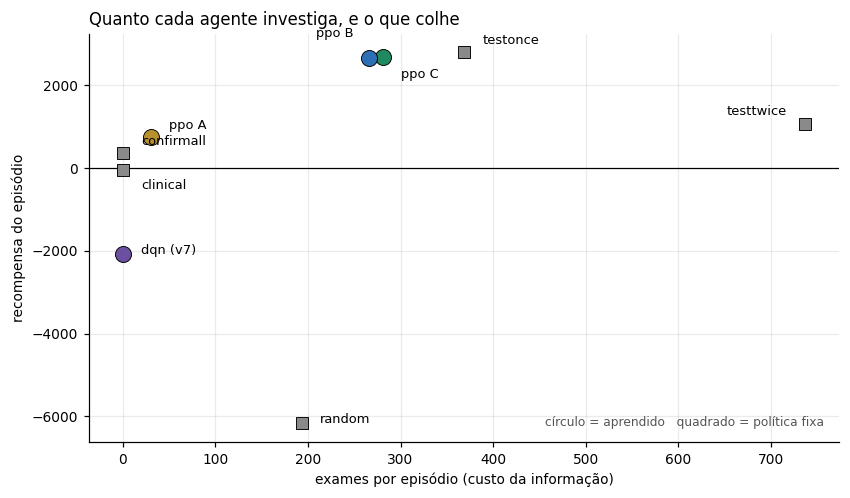

In [6]:
fig, ax = plt.subplots(figsize=(7.8, 4.6))

for _, r in todos.iterrows():
    aprendido = r["tipo"] == "aprendido"
    cor = COR["fixa"]
    if r["agente"].startswith("ppo A"): cor = COR["A"]
    elif r["agente"].startswith("ppo B"): cor = COR["B"]
    elif r["agente"].startswith("ppo C"): cor = COR["C"]
    elif aprendido: cor = "#6b4fa0"
    ax.scatter(r["exames"], r["recompensa"], s=110 if aprendido else 70,
               color=cor, marker="o" if aprendido else "s",
               edgecolor="black", linewidth=0.6, zorder=3)
    # Deslocamentos escolhidos à mão: vários agentes caem quase no mesmo ponto.
    desloca = {"ppo B": (-10, 14), "ppo C": (12, -14), "testonce": (12, 6),
               "testtwice": (-12, 6), "clinical": (12, -12), "confirmall": (12, 6),
               "ppo A": (12, 6), "dqn (v7)": (12, 0), "random": (12, 0)}
    dx, dy = desloca.get(r["agente"], (12, 4))
    ax.annotate(r["agente"], (r["exames"], r["recompensa"]),
                xytext=(dx, dy), textcoords="offset points", fontsize=8.5,
                ha="left" if dx > 0 else "right")

ax.axhline(0, color="black", lw=0.8)
ax.set_xlabel("exames por episódio (custo da informação)")
ax.set_ylabel("recompensa do episódio")
ax.set_title("Quanto cada agente investiga, e o que colhe", loc="left")
ax.text(0.98, 0.04, "círculo = aprendido   quadrado = política fixa",
        transform=ax.transAxes, ha="right", fontsize=8, color="#555")
fig.tight_layout(); fig.savefig(SAIDA / "economia.png", bbox_inches="tight")
plt.show()

**Leitura.** O eixo horizontal é o custo da informação: quantos exames o agente
compra. Os dois extremos perdem — quem não compra nada (`clinical`, `dqn`) e
quem compra em excesso (`testtwice`, ~740 exames). O ponto alto fica em comprar
**um exame por caso** (`testonce`), e os braços com crédito chegam perto dele
comprando **menos**: é o único ponto do gráfico que está à esquerda do
`testonce` e acima de todo o resto.

## 4. O modelo epidêmico, antes e depois

O gerador anterior tinha dois erros que se mascaravam: a transmissão não era
dividida pela população e o período infeccioso era de 250 dias. Um R0 declarado
de 1,5 valia 225 na prática, e a epidemia inteira cabia em ~9 dias.

O SEIR atual usa parâmetros de literatura (dengue: geração 16 d, R0 1,25–1,70;
chikungunya: 14 d, 1,46–1,67).

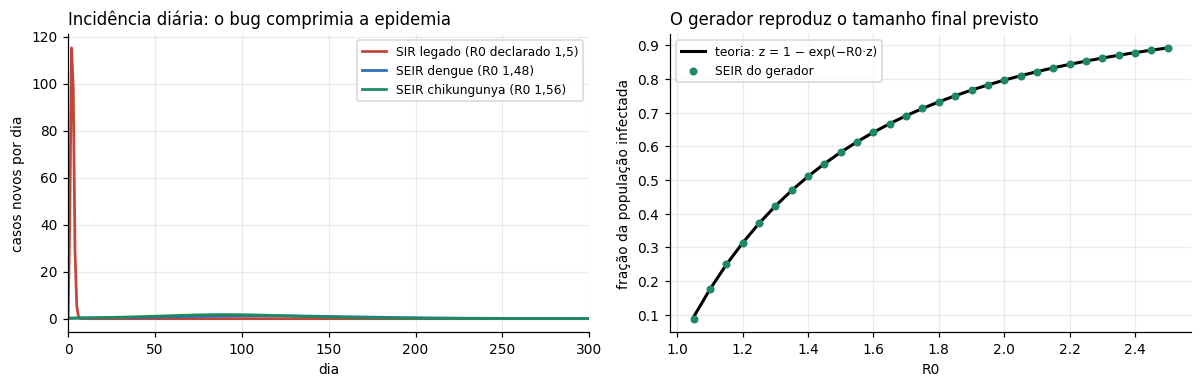

duração (5%→95% dos casos):  legado   3 dias   SEIR dengue 190 dias   SEIR chik 151 dias


In [7]:
from dengue_envs.core.epi_model import DENGUE, CHIK, legacy_sir_cumulative, seir_cumulative_cases, final_size

POP, DIAS = 300, 300
legado = legacy_sir_cumulative(popsize=POP, epilength=DIAS, r0=1.5)
seir_d = seir_cumulative_cases(1.48, DENGUE, POP, DIAS, initial_infected_fraction=0.01)
seir_c = seir_cumulative_cases(1.56, CHIK, POP, DIAS, initial_infected_fraction=0.01)

fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 3.6))
a1.plot(np.diff(legado, prepend=0), color=COR["alvo"], lw=1.8, label="SIR legado (R0 declarado 1,5)")
a1.plot(np.diff(seir_d, prepend=0), color=COR["B"], lw=1.8, label="SEIR dengue (R0 1,48)")
a1.plot(np.diff(seir_c, prepend=0), color=COR["C"], lw=1.8, label="SEIR chikungunya (R0 1,56)")
a1.set_xlim(0, DIAS); a1.set_xlabel("dia"); a1.set_ylabel("casos novos por dia")
a1.set_title("Incidência diária: o bug comprimia a epidemia", loc="left")
a1.legend(fontsize=8)

# Tamanho final: o SEIR bate a teoria; o legado infecta quase todo mundo.
r0s = np.linspace(1.05, 2.5, 30)
teorico = [final_size(r) for r in r0s]
medido = [seir_cumulative_cases(r, DENGUE, 10_000, 2000, initial_infected_fraction=1e-4)[-1] / 10_000
          for r in r0s]
a2.plot(r0s, teorico, color="black", lw=2, label="teoria: z = 1 − exp(−R0·z)")
a2.scatter(r0s, medido, s=18, color=COR["C"], zorder=3, label="SEIR do gerador")
a2.set_xlabel("R0"); a2.set_ylabel("fração da população infectada")
a2.set_title("O gerador reproduz o tamanho final previsto", loc="left")
a2.legend(fontsize=8)
fig.tight_layout(); fig.savefig(SAIDA / "modelo_epidemico.png", bbox_inches="tight")
plt.show()

def duracao(curva):
    total = curva[-1]
    return int(np.searchsorted(curva, 0.95 * total) - np.searchsorted(curva, 0.05 * total))
print(f"duração (5%→95% dos casos):  legado {duracao(legado):3d} dias   "
      f"SEIR dengue {duracao(seir_d):3d} dias   SEIR chik {duracao(seir_c):3d} dias")

**Leitura.** À esquerda, por que a correção importa: no modelo antigo tudo
acontecia numa janela de poucos dias, e o agente decidia sobre dezenas de casos
simultâneos. À direita, a verificação de que o gerador atual é consistente com a
teoria — é isso que os testes travam, em vez do formato da curva.

## 5. O último dia da epidemia, com as decisões de cada agente

Cada painel é o mapa do Rio ao fim de um episódio (todos os casos que a
vigilância chegou a notificar), com a decisão final do agente sobre cada caso:

- **verde** = diagnóstico final correto, **vermelho** = incorreto;
- **círculo** = o agente investigou o caso (pediu ao menos um exame);
- **×** = o agente não investigou (manteve o palpite clínico).

Duas seeds diferentes, lado a lado, para separar o comportamento do agente do
sorteio do surto.

In [8]:
def roda_episodio(runner, env, seed):
    env.reset(seed=int(seed)); env.action_space.seed(int(seed))
    term = trunc = False
    while not (term or trunc):
        _, _, term, trunc, _ = env.step(runner.choose_action(env))
    u = env.unwrapped
    casos = u.obs_cases.copy()
    casos["real"] = u.real_cases.loc[casos.index, "disease"].to_numpy()
    casos["acertou"] = casos["agent_diagnosis"].to_numpy() == casos["real"].to_numpy()
    casos["investigado"] = (casos["testd"].to_numpy() != 0) | (casos["testc"].to_numpy() != 0)
    return casos, u.get_episode_metrics(), int(u.t), float(u.clinical_specificity)

AGENTES = [
    ("clinical",   {}),
    ("random",     {}),
    ("confirmall", {}),
    ("testonce",   {}),
    ("testtwice",  {}),
    ("dqn",        {"checkpoints": {"dqn": str(DQN_CKPT)}}),
    ("ppo A",      {"checkpoints": {"ppo": str(RAIZ / "results/ppo_v4a_seir_s45/policy_final.pth")}}),
    ("ppo B",      {"checkpoints": {"ppo": str(RAIZ / "results/ppo_v4b_credito_s45/policy_final.pth")}}),
    ("ppo C",      {"checkpoints": {"ppo": str(RAIZ / "results/ppo_v4c_credito_sem_tempo_s45/policy_final.pth")}}),
]
# Duas seeds escolhidas pelo CONTRASTE: a especificidade do médico é sorteada a
# cada episódio, e é ela que decide quanto há a ganhar investigando.
#   seed 150 -> médico fraco (0,50: cara-ou-coroa)
#   seed 350 -> médico bom   (0,90)
SEEDS_FOTO = [150, 350]

CFG_TEMPORAL = yaml.safe_load(
    open(RAIZ / "experiments/configs/env/kriging_v8_temporal.yaml", encoding="utf-8"))

t0 = time.time()
snaps = {}
env_padrao = make_env(CFG_ENV)
env_temporal = make_env(CFG_TEMPORAL)     # o braço B observa 4 dims a mais
for nome, bench in AGENTES:
    runner = _make_runner("ppo" if nome.startswith("ppo") else nome, bench)
    env = env_temporal if nome == "ppo B" else env_padrao
    for s in SEEDS_FOTO:
        snaps[(nome, s)] = roda_episodio(runner, env, s)
env_padrao.close(); env_temporal.close()
print(f"{len(snaps)} episódios rodados em {time.time()-t0:.0f}s")

18 episódios rodados em 255s


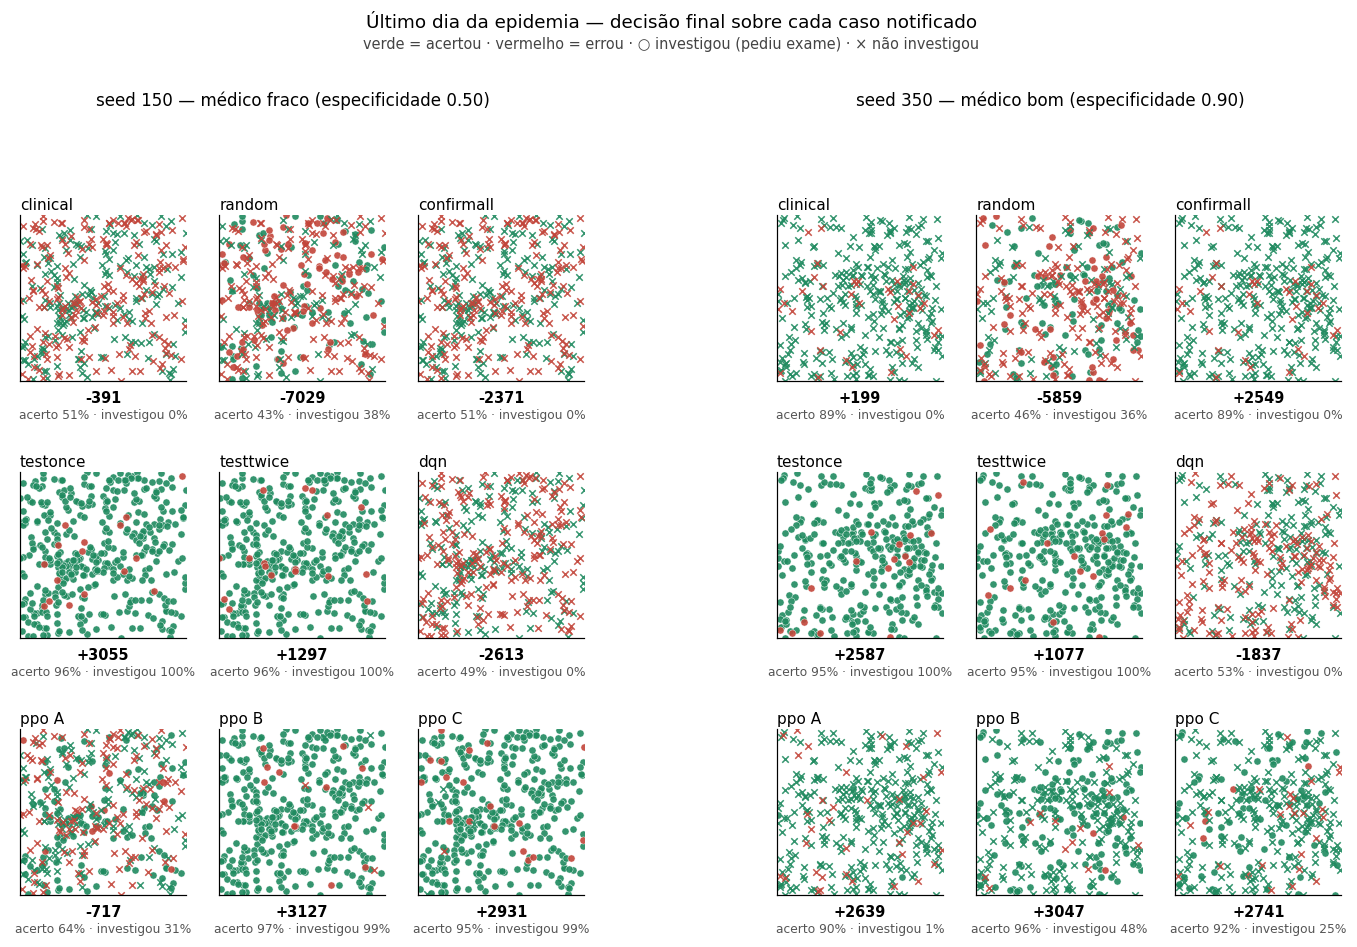

In [9]:
VERDE, VERMELHO = "#1f8a5f", "#c2453a"

def painel(ax, dados, titulo):
    casos, m, dia, espec = dados
    tamanho = CFG_ENV["env"]["size"]
    for investigado, marcador, s, lw in [(True, "o", 22, 0.3), (False, "x", 18, 1.0)]:
        sub = casos[casos["investigado"] == investigado]
        for acertou, cor in [(True, VERDE), (False, VERMELHO)]:
            p = sub[sub["acertou"] == acertou]
            ax.scatter(p["x"], p["y"], s=s, marker=marcador, c=cor, linewidths=lw,
                       edgecolors="white" if marcador == "o" else cor, alpha=0.9)
    ax.set_xlim(0, tamanho); ax.set_ylim(0, tamanho)
    ax.set_xticks([]); ax.set_yticks([]); ax.grid(False); ax.set_aspect("equal")
    ax.set_title(titulo, fontsize=10, loc="left", pad=3)
    ax.text(0.5, -0.06, f"{m['Recompensa Total']:+.0f}",
            transform=ax.transAxes, fontsize=9.5, ha="center", va="top", weight="bold")
    ax.text(0.5, -0.17,
            f"acerto {casos['acertou'].mean():.0%} · investigou {casos['investigado'].mean():.0%}",
            transform=ax.transAxes, fontsize=8, ha="center", va="top", color="#555")

nomes = [n for n, _ in AGENTES]
fig = plt.figure(figsize=(13.5, 8.6))
blocos = fig.subfigures(1, 2, wspace=0.04)

for bloco, s in zip(blocos, SEEDS_FOTO):
    espec = snaps[(nomes[0], s)][3]
    qualidade = "fraco" if espec < 0.7 else "bom"
    bloco.suptitle(f"seed {s} — médico {qualidade} (especificidade {espec:.2f})",
                   fontsize=11, y=0.985)
    axes = bloco.subplots(3, 3)
    for ax, nome in zip(axes.ravel(), nomes):
        painel(ax, snaps[(nome, s)], nome)

fig.suptitle("Último dia da epidemia — decisão final sobre cada caso notificado",
             fontsize=12, y=1.07)
fig.text(0.5, 1.03, "verde = acertou · vermelho = errou · ○ investigou (pediu exame) · × não investigou",
         ha="center", fontsize=9.5, color="#444")
fig.savefig(SAIDA / "ultimo_dia.png", bbox_inches="tight", facecolor="white")
plt.show()

In [10]:
# A mesma informação em números, para não depender da leitura visual.
linhas = []
for (nome, s), (casos, m, dia, espec) in snaps.items():
    linhas.append({"agente": nome, "seed": s, "casos": len(casos),
                   "investigados": int(casos["investigado"].sum()),
                   "acerto": round(casos["acertou"].mean(), 3),
                   "acerto_investigados": round(casos.loc[casos["investigado"], "acertou"].mean(), 3)
                        if casos["investigado"].any() else np.nan,
                   "acerto_nao_investigados": round(casos.loc[~casos["investigado"], "acertou"].mean(), 3)
                        if (~casos["investigado"]).any() else np.nan,
                   "recompensa": round(m["Recompensa Total"], 1),
                   "especificidade_do_medico": round(espec, 2)})
foto = pd.DataFrame(linhas).pivot(index="agente", columns="seed").swaplevel(axis=1).sort_index(axis=1)
display(foto)

seed          150                                                    \
           acerto acerto_investigados acerto_nao_investigados casos   
agente                                                                
clinical    0.506                 NaN                   0.506   401   
confirmall  0.506                 NaN                   0.506   401   
dqn         0.486                 NaN                   0.486   401   
ppo A       0.643               0.920                   0.518   401   
ppo B       0.965               0.972                   0.400   401   
ppo C       0.950               0.952                   0.800   401   
random      0.429               0.553                   0.353   401   
testonce    0.960               0.960                     NaN   401   
testtwice   0.958               0.958                     NaN   401   

seed                                                           350  \
           especificidade_do_medico investigados recompensa acerto   
agente                                                               
clinical                        0.5            0     -391.0  0.890   
confirmall                      0.5            0    -2371.0  0.890   
dqn                             0.5            0    -2613.0  0.527   
ppo A                           0.5          125     -717.0  0.896   
ppo B                           0.5          396     3127.0  0.958   
ppo C                           0.5          396     2931.0  0.918   
random                          0.5          152    -7029.0  0.456   
testonce                        0.5          401     3055.0  0.952   
testtwice                       0.5          401     1297.0  0.952   

seed                                                          \
           acerto_investigados acerto_nao_investigados casos   
agente                                                         
clinical                   NaN                   0.890   355   
confirmall                 NaN                   0.890   355   
dqn                        NaN                   0.527   355   
ppo A                    1.000                   0.895   355   
ppo B                    0.982                   0.935   355   
ppo C                    0.944                   0.910   355   
random                   0.609                   0.370   355   
testonce                 0.952                     NaN   355   
testtwice                0.952                     NaN   355   

seed                                                         
           especificidade_do_medico investigados recompensa  
agente                                                       
clinical                        0.9            0      199.0  
confirmall                      0.9            0     2549.0  
dqn                             0.9            0    -1837.0  
ppo A                           0.9            4     2639.0  
ppo B                           0.9          170     3047.0  
ppo C                           0.9           89     2741.0  
random                          0.9          128    -5859.0  
testonce                        0.9          355     2587.0  
testtwice                       0.9          355     1077.0

**Leitura das figuras.**

- `clinical` e `dqn` não têm um único círculo: nenhuma investigação. O mapa fica
  salpicado de vermelho onde o palpite do médico erra, e o agente não tem como
  saber onde isso acontece.
- `testtwice` investiga tudo duas vezes e acerta quase tudo — mas paga por isso,
  e a recompensa não acompanha.
- Os braços **B** e **C** são o caso interessante: parte dos casos é círculo
  (investigado), parte é × — e os × ficam majoritariamente verdes. É essa a
  competência que o ambiente cobra: gastar exame onde o palpite clínico é
  frágil, e economizar onde ele já basta.
- As duas colunas mostram por que o médico importa: com **especificidade 0,50**
  (seed 150) o palpite clínico é cara-ou-coroa e investigar rende muito; com
  **0,90** (seed 350) sobra pouco a ganhar, e mesmo assim o agente com crédito
  continua acertando.

**Cuidado ao ler.** Cada painel é **um** episódio, escolhido para ilustrar; as
conclusões quantitativas vêm das seções 1 a 3, com 3 seeds de treino × 10 de
avaliação. E o `dqn` foi treinado no ambiente antigo — está aqui como referência
histórica, não como comparação justa.

## 6. O agente investiga **quando vale a pena**?

As duas colunas da figura acima sugerem algo que as médias escondem: com médico
fraco o agente investiga quase tudo, com médico bom investiga pouco. Se isso se
confirmar nas 10 seeds de avaliação, é a competência central da tarefa — alocar
exame conforme a informação que já se tem.

A especificidade do médico é sorteada a cada episódio e **não é observável
diretamente** pelo agente: ele só vê os casos, os laudos que pediu e o mapa de
confirmados.

20 episódios em 343s
ppo C: correlação entre especificidade do médico e fração investigada = -0.89
ppo A: correlação entre especificidade do médico e fração investigada = -0.66
amplitude da recompensa entre seeds: {'ppo C': 1201, 'ppo A': 3515}


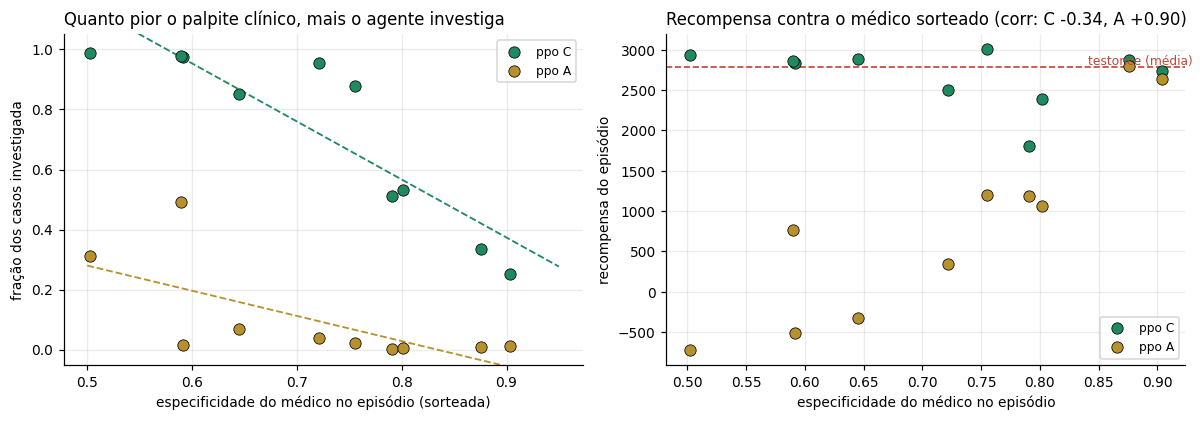

especificidade       investigou       recompensa        
agente          ppo A ppo C      ppo A ppo C      ppo A   ppo C
seed                                                           
100              0.88  0.88       0.01  0.34     2798.0  2868.0
150              0.50  0.50       0.31  0.99     -717.0  2931.0
200              0.79  0.79       0.00  0.51     1183.0  1803.0
250              0.59  0.59       0.01  0.97     -514.0  2836.0
300              0.80  0.80       0.01  0.53     1066.0  2386.0
350              0.90  0.90       0.01  0.25     2639.0  2741.0
400              0.59  0.59       0.49  0.98      762.0  2860.0
450              0.72  0.72       0.04  0.96      346.0  2496.0
500              0.76  0.76       0.02  0.88     1196.0  3004.0
550              0.64  0.64       0.07  0.85     -320.0  2886.0

In [11]:
def perfil_por_seed(nome, bench, cfg, seeds):
    env = make_env(cfg)
    runner = _make_runner("ppo" if nome.startswith("ppo") else nome, bench)
    linhas = []
    for s in seeds:
        casos, m, dia, espec = roda_episodio(runner, env, s)
        linhas.append({"agente": nome, "seed": s, "especificidade": espec,
                       "investigou": casos["investigado"].mean(),
                       "acerto": casos["acertou"].mean(),
                       "recompensa": m["Recompensa Total"]})
    env.close()
    return pd.DataFrame(linhas)

t0 = time.time()
perfil = pd.concat([
    perfil_por_seed("ppo C", {"checkpoints": {"ppo": str(RAIZ / "results/ppo_v4c_credito_sem_tempo_s45/policy_final.pth")}}, CFG_ENV, SEEDS_AVAL),
    perfil_por_seed("ppo A", {"checkpoints": {"ppo": str(RAIZ / "results/ppo_v4a_seir_s45/policy_final.pth")}}, CFG_ENV, SEEDS_AVAL),
])
print(f"{len(perfil)} episódios em {time.time()-t0:.0f}s")

fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 3.9))
for nome, cor in [("ppo C", COR["C"]), ("ppo A", COR["A"])]:
    d = perfil.query("agente == @nome")
    a1.scatter(d["especificidade"], d["investigou"], s=55, color=cor,
               edgecolor="black", linewidth=0.5, label=nome, zorder=3)
    if d["investigou"].std() > 1e-6:
        c = np.corrcoef(d["especificidade"], d["investigou"])[0, 1]
        b = np.polyfit(d["especificidade"], d["investigou"], 1)
        xs = np.linspace(0.5, 0.95, 20)
        a1.plot(xs, np.polyval(b, xs), color=cor, lw=1.2, ls="--")
        print(f"{nome}: correlação entre especificidade do médico e fração investigada = {c:+.2f}")
a1.set_xlabel("especificidade do médico no episódio (sorteada)")
a1.set_ylabel("fração dos casos investigada")
a1.set_ylim(-0.05, 1.05); a1.legend(fontsize=8)
a1.set_title("Quanto pior o palpite clínico, mais o agente investiga", loc="left")

for nome, cor in [("ppo C", COR["C"]), ("ppo A", COR["A"])]:
    d = perfil.query("agente == @nome")
    a2.scatter(d["especificidade"], d["recompensa"], s=55, color=cor,
               edgecolor="black", linewidth=0.5, label=nome, zorder=3)
a2.axhline(ALVO, color=COR["alvo"], ls="--", lw=1.1)
a2.text(0.93, ALVO, "testonce (média)", color=COR["alvo"], fontsize=8, ha="right", va="bottom")
a2.set_xlabel("especificidade do médico no episódio")
a2.set_ylabel("recompensa do episódio")
corr = {n: np.corrcoef(perfil.query("agente == @n")["especificidade"],
                       perfil.query("agente == @n")["recompensa"])[0, 1]
        for n in ("ppo C", "ppo A")}
a2.set_title(f"Recompensa contra o médico sorteado "
             f"(corr: C {corr['ppo C']:+.2f}, A {corr['ppo A']:+.2f})", loc="left")
a2.legend(fontsize=8)
print("amplitude da recompensa entre seeds:",
      {n: round(float(perfil.query("agente == @n")["recompensa"].max()
                      - perfil.query("agente == @n")["recompensa"].min())) for n in ("ppo C", "ppo A")})
fig.tight_layout(); fig.savefig(SAIDA / "adaptacao.png", bbox_inches="tight")
plt.show()

display(perfil.pivot(index="seed", columns="agente",
                     values=["especificidade", "investigou", "recompensa"]).round(2))

**Leitura.** O braço C ajusta o quanto investiga à qualidade do palpite clínico
daquele episódio — sem observar essa qualidade diretamente: ele a infere dos
laudos que vai recebendo. O braço A quase não investiga em nenhum cenário, e por
isso seu desempenho fica preso ao acaso do médico sorteado.

Esta é a evidência mais direta de que o agente aprendeu **política de alocação**,
e não apenas "pedir mais exames".